In [1]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = Path(r"D:\STUDIES\work\Work_search\jobs.db")
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM jobs", conn)
print(f"Loaded {len(df):,} jobs")
df.head()

Loaded 1,243 jobs


,id,source,external_id,title,company,location,country,description,url,posted_at,seniority,role_category,salary_min,salary_max,currency,remote,raw_json,fetched_at
0,1,jobtech,31037219,Data Engineer,Pågen AB,Malmö,SE,1 plats(er). \r\n\r\n\nData Engineer\nVälkomme...,https://arbetsformedlingen.se/platsbanken/anno...,2026-05-13T14:25:24,unspecified,data_engineer,NaN,NaN,NaN,0,"{""relevance"": 1.0, ""id"": ""31037219"", ""external...",2026-05-26T05:15:37.761736+00:00
1,2,jobtech,31030862,Data engineer,UTBETALNINGSMYNDIGHETEN,Stockholm,SE,Vill du bidra till att lösa en av vår tids stö...,https://arbetsformedlingen.se/platsbanken/anno...,2026-05-12T15:58:12,unspecified,data_engineer,NaN,NaN,NaN,0,"{""relevance"": 1.0, ""id"": ""31030862"", ""external...",2026-05-26T05:15:37.763737+00:00
2,3,jobtech,30979729,Data Engineer,Techrytera AB,Jönköping,SE,Om oss På Techrytera AB börjar rekryteringen m...,https://arbetsformedlingen.se/platsbanken/anno...,2026-04-30T11:53:20,unspecified,data_engineer,NaN,NaN,NaN,0,"{""relevance"": 1.0, ""id"": ""30979729"", ""external...",2026-05-26T05:15:37.764235+00:00
3,4,jobtech,30934475,Data Engineer,Eccera Professionals AB,Linköping,SE,Vi är specialister på bemanning och konsulttjä...,https://arbetsformedlingen.se/platsbanken/anno...,2026-04-21T11:34:14,unspecified,data_engineer,NaN,NaN,NaN,0,"{""relevance"": 1.0, ""id"": ""30934475"", ""external...",2026-05-26T05:15:37.764736+00:00
4,5,jobtech,30930181,Data Engineer,Eccera Professionals AB,Stockholm,SE,Vi är specialister på bemanning och konsulttjä...,https://arbetsformedlingen.se/platsbanken/anno...,2026-04-20T15:22:17,unspecified,data_engineer,NaN,NaN,NaN,0,"{""relevance"": 1.0, ""id"": ""30930181"", ""external...",2026-05-26T05:15:37.765236+00:00


In [2]:
junior = df[df['seniority'].isin(['junior', 'mid'])]
print(f"Total junior/mid: {len(junior)}")

junior.groupby(['country', 'role_category']).size().unstack(fill_value=0)

Total junior/mid: 75


role_category,data_engineer,ml_engineer
country,,
DE,11,9
NL,26,2
SE,19,8


Age distribution:
count    207.000000
mean      30.782609
std       32.650787
min        0.000000
25%        8.000000
50%       23.000000
75%       43.000000
max      158.000000
Name: days_old, dtype: float64


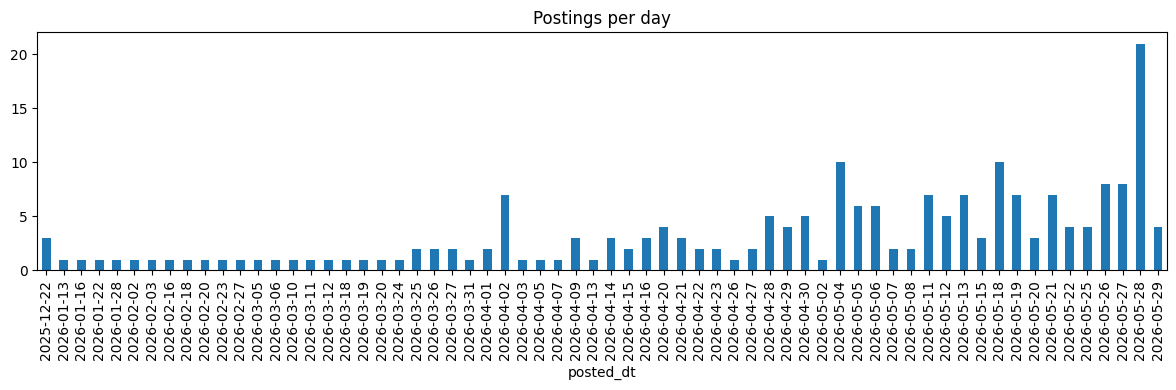

In [3]:
df['posted_dt'] = pd.to_datetime(df['posted_at'], errors='coerce', utc=True)
df['days_old'] = (pd.Timestamp.now(tz='UTC') - df['posted_dt']).dt.days

print("Age distribution:")
print(df['days_old'].describe())

# Postings per day
df.groupby(df['posted_dt'].dt.date).size().plot(kind='bar', figsize=(12, 4), title='Postings per day')
plt.tight_layout()
plt.show()

NameError: name 'sal' is not defined

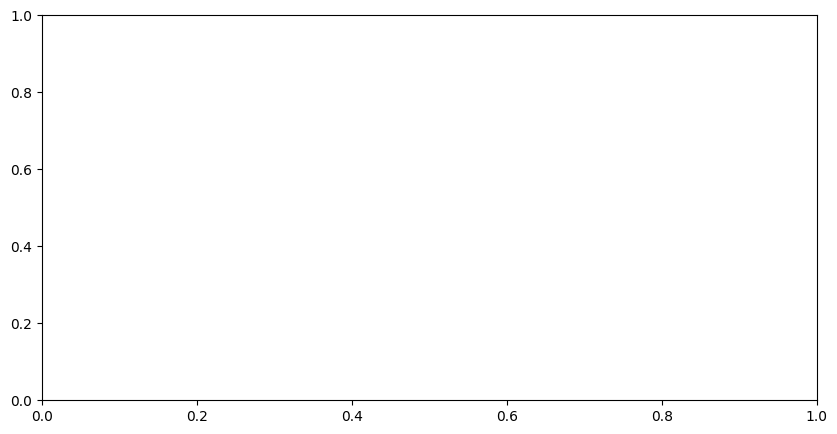

In [4]:
# Box plot of salary by country and role
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sal, x='country', y='salary_min', hue='role_category', ax=ax)
ax.set_title('Minimum salary distribution (EUR/year)')
ax.set_ylabel('Salary (min)')
plt.tight_layout()
plt.show()

In [5]:
from collections import Counter
import re

skills = [
    'python', 'sql', 'spark', 'airflow', 'dbt', 'kafka', 'snowflake',
    'databricks', 'aws', 'azure', 'gcp', 'docker', 'kubernetes',
    'pytorch', 'tensorflow', 'pandas', 'scala', 'java', 'terraform',
]

def find_skills(text):
    if not text:
        return []
    text = text.lower()
    return [s for s in skills if re.search(rf'\b{re.escape(s)}\b', text)]

df['skills'] = df['description'].fillna('').apply(find_skills)

counter = Counter()
for s in df['skills']:
    counter.update(s)

pd.DataFrame(counter.most_common(), columns=['skill', 'jobs']).head(15)

,skill,jobs
0,python,165
1,sql,127
2,azure,124
3,aws,97
4,databricks,96
5,snowflake,52
6,gcp,50
7,dbt,47
8,spark,39
9,airflow,34


In [6]:
# Change this and re-run the cell
search = "kafka"

matches = df[df['description'].fillna('').str.contains(search, case=False)]
print(f"'{search}' appears in {len(matches)} postings ({len(matches)/len(df)*100:.1f}%)")
print(matches[['title', 'company', 'country', 'seniority']].head(10))

'kafka' appears in 20 postings (1.6%)
                                 title                         company  \
11                       Data Engineer  Sigma Technology Experience AB   
17                       Data Engineer                   Silverspin AB   
21                       Data Engineer                     Redeploy AB   
26                       Data Engineer                  Klarna Bank AB   
33        Data Scientist/Data Engineer           Integro Consulting AB   
34                Junior Data Engineer                    Deer Data AB   
37                Senior Data Engineer              Mpya Sci & Tech AB   
42                Senior Data Engineer                 Sinch Sweden AB   
46  Data Engineer - Data Platform Team                   Aira Group AB   
99       Senior Data Platform Engineer                 Kambi Sweden AB   

   country    seniority  
11      SE       senior  
17      SE  unspecified  
21      SE       senior  
26      SE  unspecified  
33      SE       

In [7]:
df['desc_len'] = df['description'].fillna('').str.len()
df.groupby('source')['desc_len'].agg(['count', 'mean', 'median', 'max']).round(0)


,count,mean,median,max
source,,,,
adzuna,1022,500.0,500.0,500
arbeitnow,5,6212.0,6031.0,9299
jobtech,207,3528.0,3307.0,6471
nav,9,16.0,16.0,16


In [8]:
out = df[df['seniority'].isin(['junior', 'mid', 'unspecified'])][
    ['country', 'company', 'title', 'location', 'role_category', 'posted_at', 'url']
].sort_values(['country', 'company'])

print(f"Found {len(out)} jobs (junior + mid + unspecified)")
out.to_csv('entry_friendly_jobs.csv', index=False, encoding='utf-8-sig')

Found 732 jobs (junior + mid + unspecified)


In [9]:
juniors = df[df['seniority'] == 'junior'][
    ['country', 'company', 'title', 'location', 'role_category',
     'posted_at', 'url', 'description']
].sort_values(['country', 'company']).reset_index(drop=True)

print(f"Found {len(juniors)} junior jobs\n")

# Show full description, no truncation, in the table
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
juniors

Found 61 junior jobs



,country,company,title,location,role_category,posted_at,url,description
0,DE,&effect,Junior Data Engineer / Data Scientist (m/w/d),"Prenzlauer Berg, Berlin",data_engineer,2026-05-12T22:40:53Z,https://www.adzuna.de/details/5727211826?utm_medium=api&utm_source=8c0e11bf,"Über &effect &effect unterstützt Organisation im sozialen und öffentlichen Sektor ihre Daten für einen positiven Impact einsetzen zu können. Dabei setzen wir auf datengesteuerte Prozesse und evidenzbasierte Entscheidungen. Als interdisziplinäres Team wollen wir unsere Fähigkeiten nutzen, um etwas zu verändern! Wir entwickeln Daten- und Softwareprodukte, um Datensilos aufzubrechen, unstrukturierte Daten nutzbar zu machen und die Datenkommunikation einfach, wirkungsvoll und schön zu gestalten. Wi…"
1,DE,Atos,Junior Data Engineer (m/w/d),"Kernstadt, Paderborn",data_engineer,2024-02-09T11:07:54Z,https://www.adzuna.de/details/4563362554?utm_medium=api&utm_source=8c0e11bf,"Eviden ist ein Unternehmen der Atos-Gruppe mit einem Jahresumsatz von ca. 5 Mrd. EUR und weltweit führend bei der datengesteuerten, vertrauenswürdigen und nachhaltigen digitalen Transformation. Als digitales Unternehmen der nächsten Generation mit weltweit führenden Positionen in den Bereichen Digital, Cloud, Data, Advanced Computing und Digital Security verfügt Eviden über fundiertes Fachwissen für alle Branchen in mehr als 47 Ländern. Durch die Kombination einzigartiger High-End-Technologien …"
2,DE,Autonomous Teaming,Junior Robotics Infrastructure Engineer (m/f/d) - CI/CD & Build Systems,Deutschland,ml_engineer,2026-05-26T23:05:01Z,https://www.adzuna.de/details/5741608187?utm_medium=api&utm_source=8c0e11bf,"What we offer Work in an international, agile team creating the future of autonomous systems Grow your career in a expanding and ambitious engineering team Build innovative products using state-of-the-art technologies in AI, robotics, and autonomy Benefit from a steep learning curve and continuous development Enjoy team events and a strong, collaborative culture Your mission Build and maintain the systems that allow our robotics software to be reliably developed, tested, and deployed. You’ll wo…"
3,DE,Chrono24,Junior Data Engineer (m/w/d),"Hagsfeld, Karlsruhe",data_engineer,2026-05-12T23:33:42Z,https://www.adzuna.de/details/5727351309?utm_medium=api&utm_source=8c0e11bf,"Beschreibung Als Data Engineer sorgst du dafür, dass alle relevanten Daten in unserer Plattform verfügbar und nutzbar sind. Du bindest neue Quellen an, bereitest Daten auf und entwickelst unser Data Warehouse weiter. Mit deinem Zahlenverständnis und Blick fürs Detail machst du Daten für Chrono24 strategisch nutzbar. Du arbeitest hybrid und bist zwei Tage vor Ort an unserem Hauptstandort in Karlsruhe. Darauf kannst Du dich freuen Du unterstützt bei der Integration von Daten aus verschiedenen Que…"
4,DE,Dymatrix,(Junior) Cloud Data Engineer (all genders),"Mitte, Stuttgart",data_engineer,2026-05-26T22:53:56Z,https://www.adzuna.de/details/5741527100?utm_medium=api&utm_source=8c0e11bf,"Allgemein: In einem interdisziplinären Projektteam übernimmst Du den Part der technischen Umsetzung von Datenverarbeitungsstrecken in Batch und Realtime. Als Experte für das Data Engineering bist Du im Projekt Ansprechpartner für Kollegen und Kunden. Mit modernen cloud-basierten Technologien generierst Du - KI-unterstützt - innovative Lösungen rund um unsere Produkte. Wir suchen Dich mit und ohne Berufserfahrung, als (Junior) Data Engineer (all genders) für unsere Standorte in Karlsruhe, Stuttg…"
5,DE,Frankfurter Allgemeine Zeitung GmbH,(Junior) Data Engineer (m/w/d),"Altstadt, Frankfurt am Main",data_engineer,2026-05-13T02:29:49Z,https://www.adzuna.de/details/5727444581?utm_medium=api&utm_source=8c0e11bf,Frankfurt am Main | Product Sales | Vollzeit | befristet für zwei Jahre | ab sofort / nach Verfügbarkeit (Junior) Data Engineer (m/w/d) Die Frankfurter Allgemeine Zeitung ist weit über die Landesgrenzen hinaus für ihren ausgezeichneten Journalismus be

In [10]:
# Dedupe by (company, title, location) keeping the most recent
juniors_clean = (df[df['seniority'] == 'junior']
                 .sort_values('posted_at', ascending=False)
                 .drop_duplicates(subset=['company', 'title', 'location'], keep='first')
                 .reset_index(drop=True))

print(f"Junior jobs after dedup: {len(juniors_clean)} (was {(df['seniority']=='junior').sum()})")
juniors_clean[['country', 'company', 'title', 'location', 'posted_at', 'url']]

Junior jobs after dedup: 51 (was 61)


,country,company,title,location,posted_at,url
0,NL,All About Work,Data-Analist / (Junior) Data-Engineer,"Lichtenvoorde, Oost Gelre",2026-05-28T16:48:52Z,https://www.adzuna.nl/details/5743556009?utm_medium=api&utm_source=8c0e11bf
1,SE,Sway Sourcing Sweden Aktiebolag,Junior Data Engineer – Malmö 🚆,Malmö,2026-05-28T12:11:57,https://arbetsformedlingen.se/platsbanken/annonser/31096160
2,NL,Bright Professionals,Data-Analist / Junior Data-Engineer,"Oost Gelre, Gelderland",2026-05-28T07:35:33Z,https://www.adzuna.nl/details/5743142370?utm_medium=api&utm_source=8c0e11bf
3,DE,Reply Deutschland SE,"(Junior) Machine Learning Engineer (m/w/d) - System Engineering / Admin, Ingenieur","Berlin, Deutschland",2026-05-27T09:06:13Z,https://www.adzuna.de/details/5742024605?utm_medium=api&utm_source=8c0e11bf
4,DE,Reply Deutschland SE,"(Junior) Machine Learning Engineer (m/w/d) - System Engineering / Admin, Ingenieur","München, München (Kreis)",2026-05-27T09:06:13Z,https://www.adzuna.de/details/5742024606?utm_medium=api&utm_source=8c0e11bf
5,DE,Autonomous Teaming,Junior Robotics Infrastructure Engineer (m/f/d) - CI/CD & Build Systems,Deutschland,2026-05-26T23:05:01Z,https://www.adzuna.de/details/5741608187?utm_medium=api&utm_source=8c0e11bf
6,DE,Dymatrix,(Junior) Cloud Data Engineer (all genders),"Mitte, Stuttgart",2026-05-26T22:53:56Z,https://www.adzuna.de/details/5741527100?utm_medium=api&utm_source=8c0e11bf
7,SE,ESAB AB,Development Engineer-R&D Filler Metals (SAW),Göteborg,2026-05-25T12:56:40,https://arbetsformedlingen.se/platsbanken/annonser/31078336
8,NL,WEBB Traders BV,Junior/Medior Data Engineer - Finance,"Amsterdam, Noord-Holland",2026-05-25T07:01:20Z,https://www.adzuna.nl/details/5740215380?utm_medium=api&utm_source=8c0e11bf
9,NL,Samba,Software Engineer - Data Integration,"Amsterdam, Noord-Holland",2026-05-22T03:23:31Z,https://www.adzuna.nl/details/5737084059?utm_medium=api&utm_source=8c0e11bf


In [11]:
import re

JUNIOR_TITLE = re.compile(r'\b(junior|jr\.?|entry[- ]level|graduate|trainee|associate|intern|'
                          r'starter|nyutexaminerad|berufseinsteiger|absolvent|early talent|'
                          r'data[- ]?analist)\b', re.I)
SENIOR_TITLE = re.compile(r'\b(senior|sr\.?|lead|principal|staff|head of|architect|expert|'
                          r'medior|consultant)\b', re.I)
MID_TITLE    = re.compile(r'\b(mid[- ]level|intermediate|medior|junior/medior|medior/senior)\b', re.I)

def reclassify(row):
    title = row['title'] or ''
    desc  = (row['description'] or '')[:300]  # only first 300 chars of description
    # Senior in the title wins — even "Junior/Senior" leans senior
    if SENIOR_TITLE.search(title):
        return 'senior'
    if MID_TITLE.search(title):
        return 'mid'
    if JUNIOR_TITLE.search(title):
        return 'junior'
    # Only check description briefly, and only for explicit entry markers
    if re.search(r'\b(no prior experience|0[- ]?2 years|fresh graduate|entry[- ]level)\b', desc, re.I):
        return 'junior'
    return 'unspecified'

df['seniority_v2'] = df.apply(reclassify, axis=1)

# Compare
print("Old classifier:")
print(df['seniority'].value_counts())
print("\nNew classifier:")
print(df['seniority_v2'].value_counts())

Old classifier:
seniority
unspecified    657
senior         511
junior          61
mid             14
Name: count, dtype: int64

New classifier:
seniority_v2
unspecified    700
senior         478
junior          65
Name: count, dtype: int64


In [12]:
real_juniors = (df[df['seniority_v2'] == 'junior']
                .sort_values('posted_at', ascending=False)
                .drop_duplicates(subset=['company', 'title', 'location'], keep='first')
                [['country', 'company', 'title', 'location', 'posted_at', 'url']]
                .reset_index(drop=True))

print(f"Real junior jobs: {len(real_juniors)}")
real_juniors

Real junior jobs: 54


,country,company,title,location,posted_at,url
0,NL,Bynder,AI Research Intern,"Rotterdam, Zuid-Holland",2026-05-30T03:27:36Z,https://www.adzuna.nl/details/5745092366?utm_medium=api&utm_source=8c0e11bf
1,NL,adidas,Intern - Digital Data Science and Analytics,"Amsterdam, Noord-Holland",2026-05-29T02:28:35Z,https://www.adzuna.nl/details/5744032118?utm_medium=api&utm_source=8c0e11bf
2,NL,All About Work,Data-Analist / (Junior) Data-Engineer,"Lichtenvoorde, Oost Gelre",2026-05-28T16:48:52Z,https://www.adzuna.nl/details/5743556009?utm_medium=api&utm_source=8c0e11bf
3,SE,Sway Sourcing Sweden Aktiebolag,Junior Data Engineer – Malmö 🚆,Malmö,2026-05-28T12:11:57,https://arbetsformedlingen.se/platsbanken/annonser/31096160
4,NL,Bright Professionals,Data-Analist / Junior Data-Engineer,"Oost Gelre, Gelderland",2026-05-28T07:35:33Z,https://www.adzuna.nl/details/5743142370?utm_medium=api&utm_source=8c0e11bf
5,DE,Reply Deutschland SE,"(Junior) Machine Learning Engineer (m/w/d) - System Engineering / Admin, Ingenieur","München, München (Kreis)",2026-05-27T09:06:13Z,https://www.adzuna.de/details/5742024606?utm_medium=api&utm_source=8c0e11bf
6,DE,Reply Deutschland SE,"(Junior) Machine Learning Engineer (m/w/d) - System Engineering / Admin, Ingenieur","Berlin, Deutschland",2026-05-27T09:06:13Z,https://www.adzuna.de/details/5742024605?utm_medium=api&utm_source=8c0e11bf
7,DE,Autonomous Teaming,Junior Robotics Infrastructure Engineer (m/f/d) - CI/CD & Build Systems,Deutschland,2026-05-26T23:05:01Z,https://www.adzuna.de/details/5741608187?utm_medium=api&utm_source=8c0e11bf
8,DE,Dymatrix,(Junior) Cloud Data Engineer (all genders),"Mitte, Stuttgart",2026-05-26T22:53:56Z,https://www.adzuna.de/details/5741527100?utm_medium=api&utm_source=8c0e11bf
9,DE,autonomous-teaming,Junior Robotics Infrastructure Engineer (m/f/d) - CI/CD & Build Systems,"Milbertshofen-Am Hart, München",2026-05-20T10:54:10Z,https://www.adzuna.de/details/5734997786?utm_medium=api&utm_source=8c0e11bf


In [13]:
# Dedupe by (company + title + month-of-posting), keeping earliest
df['posted_month'] = pd.to_datetime(df['posted_at'], errors='coerce', utc=True).dt.to_period('M')

real_juniors = (df[df['seniority_v2'] == 'junior']
                .sort_values('posted_at')
                .drop_duplicates(subset=['company', 'title', 'posted_month'], keep='first')
                .sort_values('posted_at', ascending=False)
                [['country', 'company', 'title', 'location', 'posted_at', 'url']]
                .reset_index(drop=True))

print(f"Real junior jobs after dedup: {len(real_juniors)}")
real_juniors

Real junior jobs after dedup: 41


C:\Users\skard\AppData\Local\Temp\ipykernel_11944\1667294826.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['posted_month'] = pd.to_datetime(df['posted_at'], errors='coerce', utc=True).dt.to_period('M')


,country,company,title,location,posted_at,url
0,NL,Bynder,AI Research Intern,"Rotterdam, Zuid-Holland",2026-05-30T03:27:36Z,https://www.adzuna.nl/details/5745092366?utm_medium=api&utm_source=8c0e11bf
1,NL,adidas,Intern - Digital Data Science and Analytics,"Amsterdam, Noord-Holland",2026-05-29T02:28:35Z,https://www.adzuna.nl/details/5744032118?utm_medium=api&utm_source=8c0e11bf
2,NL,All About Work,Data-Analist / (Junior) Data-Engineer,"Lichtenvoorde, Oost Gelre",2026-05-28T16:48:52Z,https://www.adzuna.nl/details/5743556009?utm_medium=api&utm_source=8c0e11bf
3,SE,Sway Sourcing Sweden Aktiebolag,Junior Data Engineer – Malmö 🚆,Malmö,2026-05-28T11:05:51,https://arbetsformedlingen.se/platsbanken/annonser/31095162
4,NL,Bright Professionals,Data-Analist / Junior Data-Engineer,"Oost Gelre, Gelderland",2026-05-28T07:35:33Z,https://www.adzuna.nl/details/5743142370?utm_medium=api&utm_source=8c0e11bf
5,DE,Reply Deutschland SE,"(Junior) Machine Learning Engineer (m/w/d) - System Engineering / Admin, Ingenieur","München, München (Kreis)",2026-05-27T09:06:13Z,https://www.adzuna.de/details/5742024606?utm_medium=api&utm_source=8c0e11bf
6,DE,Autonomous Teaming,Junior Robotics Infrastructure Engineer (m/f/d) - CI/CD & Build Systems,Deutschland,2026-05-26T23:05:01Z,https://www.adzuna.de/details/5741608187?utm_medium=api&utm_source=8c0e11bf
7,DE,Dymatrix,(Junior) Cloud Data Engineer (all genders),"Mitte, Stuttgart",2026-05-26T22:53:56Z,https://www.adzuna.de/details/5741527100?utm_medium=api&utm_source=8c0e11bf
8,DE,autonomous-teaming,Junior Robotics Infrastructure Engineer (m/f/d) - CI/CD & Build Systems,"Milbertshofen-Am Hart, München",2026-05-20T10:54:10Z,https://www.adzuna.de/details/5734997786?utm_medium=api&utm_source=8c0e11bf
9,SE,Deer Data AB,Junior Data Engineer,Solna,2026-05-19T07:01:55,https://arbetsformedlingen.se/platsbanken/annonser/31051057


In [14]:
import re
import pandas as pd
from collections import Counter

# --- 1. Skill vocabulary ---
SKILLS = [
    # Languages
    'python', 'sql', 'scala', 'java', 'r', 'go', 'rust', 'c++', 'typescript', 'javascript',
    # Data engineering
    'spark', 'pyspark', 'hadoop', 'kafka', 'flink', 'airflow', 'dbt', 'dagster', 'prefect',
    'snowflake', 'databricks', 'bigquery', 'redshift', 'delta lake', 'iceberg',
    'azure data factory', 'medallion architecture', 'data vault', 'etl', 'elt',
    # Databases
    'postgresql', 'postgres', 'mysql', 'mongodb', 'cassandra', 'elasticsearch',
    'clickhouse', 'redis', 'dynamodb',
    # ML / DS
    'pytorch', 'tensorflow', 'keras', 'scikit-learn', 'sklearn', 'xgboost', 'lightgbm',
    'huggingface', 'langchain', 'mlflow', 'kubeflow', 'sagemaker', 'vertex ai',
    'pandas', 'numpy', 'spacy', 'nlp', 'computer vision', 'llm', 'transformers',
    'rag', 'genai',
    # Cloud
    'aws', 'azure', 'gcp', 'google cloud', 'microsoft fabric', 'fabric',
    # DevOps / infra
    'docker', 'kubernetes', 'k8s', 'terraform', 'ansible', 'jenkins', 'gitlab',
    'github actions', 'ci/cd',
    # BI / streaming
    'kinesis', 'pubsub', 'tableau', 'power bi', 'looker', 'superset', 'metabase',
]

# Longest first so "pyspark" wins over "spark", "delta lake" wins over "delta"
SKILLS = sorted(set(SKILLS), key=len, reverse=True)

PATTERNS = {
    s: re.compile(rf'(?<![A-Za-z0-9+#]){re.escape(s)}(?![A-Za-z0-9+#])', re.IGNORECASE)
    for s in SKILLS
}

# Canonicalize variants
CANON = {
    'sklearn': 'scikit-learn', 'postgres': 'postgresql', 'k8s': 'kubernetes',
    'google cloud': 'gcp', 'fabric': 'microsoft fabric', 'pyspark': 'spark',
}

def extract_skills(text: str) -> list[str]:
    if not text:
        return []
    found = set()
    for skill, pat in PATTERNS.items():
        if pat.search(text):
            found.add(CANON.get(skill, skill))
    # Return sorted for stable output
    return sorted(found)

# --- 2. Apply to shortlist (combine title + description so we don't miss skills in either) ---
shortlist = shortlist.copy()  # avoid SettingWithCopyWarning
shortlist['skills'] = shortlist.apply(
    lambda r: extract_skills(f"{r.get('title','')} {df.loc[r.name, 'description'] if r.name in df.index else ''}"),
    axis=1,
)

# If the join above doesn't line up (because of resets), use this safer version instead:
# Join back to df on url to pull descriptions
shortlist = shortlist.merge(df[['url', 'description']], on='url', how='left')
shortlist['skills'] = shortlist['description'].fillna('').apply(extract_skills)
shortlist['skill_count'] = shortlist['skills'].apply(len)

# --- 3. Pretty display ---
display_cols = ['country', 'company', 'title', 'location', 'posted_at', 'skills', 'url']
pd.set_option('display.max_colwidth', None)
shortlist[display_cols]

NameError: name 'shortlist' is not defined

In [15]:
import re
import pandas as pd
from collections import Counter

# ============================================================
# 1. Reclassify seniority (title-first, ignore "mentor junior" false positives)
# ============================================================
JUNIOR_TITLE = re.compile(r'\b(junior|jr\.?|entry[- ]level|graduate|trainee|associate|'
                          r'starter|nyutexaminerad|berufseinsteiger|absolvent|early talent|'
                          r'data[- ]?analist)\b', re.I)
SENIOR_TITLE = re.compile(r'\b(senior|sr\.?|lead|principal|staff|head of|architect|expert|'
                          r'consultant)\b', re.I)
MID_TITLE    = re.compile(r'\b(mid[- ]level|intermediate|medior|junior/medior)\b', re.I)

def reclassify(row):
    title = row['title'] or ''
    if SENIOR_TITLE.search(title): return 'senior'
    if MID_TITLE.search(title):    return 'mid'
    if JUNIOR_TITLE.search(title): return 'junior'
    return 'unspecified'

df['seniority_v2'] = df.apply(reclassify, axis=1)

# ============================================================
# 2. Build shortlist: junior + recent + no interns + deduped
# ============================================================
INTERN_RE = re.compile(r'\b(intern|internship|stage|afstudeerstage|werkstudent|'
                       r'working student|praktikum|praktikant)\b', re.I)

df['posted_dt'] = pd.to_datetime(df['posted_at'], errors='coerce', utc=True)
df['posted_month'] = df['posted_dt'].dt.to_period('M')

cutoff = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=60)

shortlist = (df[
        (df['seniority_v2'] == 'junior') &
        (~df['title'].str.contains(INTERN_RE, na=False)) &
        (df['posted_dt'] > cutoff)
    ]
    .sort_values('posted_at')
    .drop_duplicates(subset=['company', 'title', 'posted_month'], keep='first')
    .sort_values('posted_at', ascending=False)
    .reset_index(drop=True))

print(f"Shortlist: {len(shortlist)} jobs")
print(shortlist['country'].value_counts().to_string())

# ============================================================
# 3. Skill extraction
# ============================================================
SKILLS = [
    'python', 'sql', 'scala', 'java', 'r', 'go', 'rust', 'c++', 'typescript', 'javascript',
    'spark', 'pyspark', 'hadoop', 'kafka', 'flink', 'airflow', 'dbt', 'dagster', 'prefect',
    'snowflake', 'databricks', 'bigquery', 'redshift', 'delta lake', 'iceberg',
    'azure data factory', 'medallion architecture', 'data vault', 'etl', 'elt',
    'postgresql', 'postgres', 'mysql', 'mongodb', 'cassandra', 'elasticsearch',
    'clickhouse', 'redis', 'dynamodb',
    'pytorch', 'tensorflow', 'keras', 'scikit-learn', 'sklearn', 'xgboost', 'lightgbm',
    'huggingface', 'langchain', 'mlflow', 'kubeflow', 'sagemaker', 'vertex ai',
    'pandas', 'numpy', 'spacy', 'nlp', 'computer vision', 'llm', 'transformers',
    'rag', 'genai',
    'aws', 'azure', 'gcp', 'google cloud', 'microsoft fabric', 'fabric',
    'docker', 'kubernetes', 'k8s', 'terraform', 'ansible', 'jenkins', 'gitlab',
    'github actions', 'ci/cd',
    'kinesis', 'pubsub', 'tableau', 'power bi', 'looker', 'superset', 'metabase',
]
SKILLS = sorted(set(SKILLS), key=len, reverse=True)
PATTERNS = {s: re.compile(rf'(?<![A-Za-z0-9+#]){re.escape(s)}(?![A-Za-z0-9+#])', re.IGNORECASE)
            for s in SKILLS}
CANON = {'sklearn': 'scikit-learn', 'postgres': 'postgresql', 'k8s': 'kubernetes',
         'google cloud': 'gcp', 'fabric': 'microsoft fabric', 'pyspark': 'spark'}

def extract_skills(text):
    if not text: return []
    found = set()
    for skill, pat in PATTERNS.items():
        if pat.search(text):
            found.add(CANON.get(skill, skill))
    return sorted(found)

shortlist['skills'] = (shortlist['title'].fillna('') + ' ' + shortlist['description'].fillna('')).apply(extract_skills)
shortlist['skill_count'] = shortlist['skills'].apply(len)

# ============================================================
# 4. Display
# ============================================================
pd.set_option('display.max_colwidth', None)
shortlist[['country', 'company', 'title', 'location', 'posted_at', 'skills', 'url']]

Shortlist: 2 jobs
country
SE    2


C:\Users\skard\AppData\Local\Temp\ipykernel_11944\3971943101.py:31: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['posted_month'] = df['posted_dt'].dt.to_period('M')
C:\Users\skard\AppData\Local\Temp\ipykernel_11944\3971943101.py:37: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (~df['title'].str.contains(INTERN_RE, na=False)) &


,country,company,title,location,posted_at,skills,url
0,SE,Sway Sourcing Sweden Aktiebolag,Junior Data Engineer – Malmö 🚆,Malmö,2026-05-28T11:05:51,"[azure, azure data factory, databricks, delta lake, etl, medallion architecture, power bi, python, r, sql]",https://arbetsformedlingen.se/platsbanken/annonser/31095162
1,SE,Deer Data AB,Junior Data Engineer,Solna,2026-05-19T07:01:55,"[airflow, aws, azure, bigquery, ci/cd, dagster, dbt, docker, elt, etl, gcp, kafka, looker, metabase, power bi, python, redshift, snowflake, sql, terraform]",https://arbetsformedlingen.se/platsbanken/annonser/31051057
